In [ ]:
import os
from src.plotting import load_and_sample_image, plot_rgb_space, plot_log_rgb_space
from tqdm import tqdm

# Example 1: Basic RGB/log-RGB visualization
image_dir = "data/"

# Get ONLY .DNG images in data
images = [f for f in os.listdir(image_dir) if f.endswith(".png")]

for image_path in tqdm(images):
    full_image_path = os.path.join(image_dir, image_path)
    image_name = image_path.split(".")[0]

    # LOAD AND SAMPLE THE IMAGE
    print("Loading and sampling image...")
    pixels, colors = load_and_sample_image(full_image_path,
                                           num_samples=100000,
                                           device='cuda')

    # Plot RGB space
    print("Plotting RGB space...")
    plot_rgb_space(pixels, colors,
                   title=f"RGB Space - {image_name}",
                   save_path=f"results/rgb_{image_name}.png",
                   alpha=0.3, point_size=2)

    # Plot log-RGB space
    print("Plotting log-RGB space...")
    plot_log_rgb_space(pixels, colors,
                       title=f"Log-RGB Space - {image_name}",
                       save_path=f"results/log_rgb_{image_name}.png",
                       alpha=0.3, point_size=2)


In [4]:
from src.models import ResNet50UNet
from src.plotting import visualize_isd_output
from src.transformation import apply_isd_darkening_log
import numpy as np
from PIL import Image
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# UNET MODEL
print("Initializing model...")
model = ResNet50UNet(
            in_channels=3,
            out_channels=3,
            pretrained=True,
            checkpoint="src/weights/UNET_best_model.pth",
            se_block=True,
            dropout=0.0
        ).to(device)
model.eval()

# Load image
img_path = "data/twilight_crop_mini.png"
print(f"Loading {img_path}...")
img_srgb = np.array(Image.open(img_path).convert('RGB')).astype(np.float32) / 255.0
img_linear = np.where(
    img_srgb <= 0.04045,
    img_srgb / 12.92,
    ((img_srgb + 0.055) / 1.055) ** 2.4
)
epsilon = 1e-6
log_img = np.log(img_linear + epsilon)


# Run inference
print("Running ISD estimation...")
img_tensor = torch.from_numpy(img_linear).permute(2, 0, 1).to(device)
batch_tensor = torch.unsqueeze(img_tensor, dim=0)

with torch.no_grad():
    prediction = model(batch_tensor)
    norm_pred = torch.norm(prediction, dim=1, keepdim=True)
    predicted_norm = torch.where(norm_pred != 0,
                                 prediction / norm_pred,
                                 prediction)

predicted_isds = predicted_norm[0].cpu().detach().numpy()  # (3, H, W)

# Create all visualizations
#visualize_isd_output(predicted_isds, log_img, output_prefix="sunset_isd")

print("Applying ISD darkening...")
strengths = [150]
for s in strengths:
    print("Applying ISD darkening (log-space)...")
    log_darkened = apply_isd_darkening_log(log_img, predicted_isds, strength=s/100)

    # Back to linear
    linear_dark = np.exp(log_darkened)
    linear_dark = np.clip(linear_dark, 0, 1)

    # Linear → sRGB
    srgb_dark = np.where(
        linear_dark <= 0.0031308,
        linear_dark * 12.92,
        1.055 * (linear_dark ** (1/2.4)) - 0.055
    )
    srgb_dark = (np.clip(srgb_dark, 0, 1) * 255).astype(np.uint8)

    out_path = f"data/sunset_darkened_s{s}.png"
    Image.fromarray(srgb_dark).save(out_path)
    print(f"Saved correctly darkened image to {out_path}")


print("All done!")

cuda
Initializing model...
Loading data/twilight_crop_mini.png...
Running ISD estimation...
Applying ISD darkening...
Applying ISD darkening (log-space)...
Saved correctly darkened image to data/sunset_darkened_s150.png
All done!


In [13]:
from src.map_ViT_models import ViT_Patch2Patch_ver2
from src.plotting import visualize_isd_output
import numpy as np
from PIL import Image
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# ViT MODEL
model = ViT_Patch2Patch_ver2(
                img_size=512,
                patch_size=16,
                in_ch=3,
                out_ch=3,
                embed_dim=768,
                depth=4,
                heads=8,
                dropout=0.1
            ).to(device)

# Load weights
model.load_state_dict(torch.load("src/weights/ViT_best_model.pth"))
model.eval()

# Load image
img_path = "data/sunset_crop_mini.png"
print(f"Loading {img_path}...")
img_srgb = np.array(Image.open(img_path).convert('RGB')).astype(np.float32) / 255.0
img_linear = np.where(
    img_srgb <= 0.04045,
    img_srgb / 12.92,
    ((img_srgb + 0.055) / 1.055) ** 2.4
)
epsilon = 1e-6
log_img = np.log(img_linear + epsilon)

# Run inference
print("Running ISD estimation...")
img_tensor = torch.from_numpy(img_linear).permute(2, 0, 1).to(device)
batch_tensor = torch.unsqueeze(img_tensor, dim=0)

with torch.no_grad():
    prediction = model(batch_tensor)
    norm_pred = torch.norm(prediction, dim=1, keepdim=True)
    predicted_norm = torch.where(norm_pred != 0,
                                 prediction / norm_pred,
                                 prediction)

predicted_isds = predicted_norm[0].cpu().detach().numpy()  # (3, H, W)

# Create all visualizations
visualize_isd_output(predicted_isds, log_img, output_prefix="sunset_isd")

print("\n✓ Done! Check the generated images.")

C:\Users\MaxHu\anaconda3\envs\py-3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'ViTModel' from partially initialized module 'src.map_ViT_models' (most likely due to a circular import) (C:\Users\MaxHu\CLASS DOCS\Perception\FINAL PROJECT\src\map_ViT_models.py)

cuda
Direct illumination: [0.78762037 0.81792694 0.86936724]


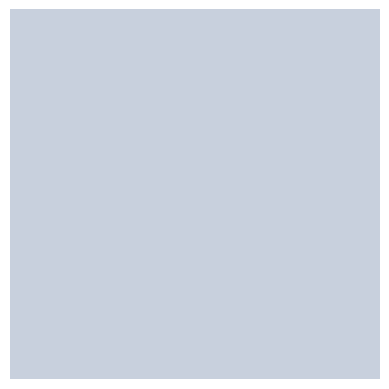

In [2]:
from src.illuminant_estimation import FastRetinexIlluminant
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

img_path = "data/sunset_crop_mini.png"

# Fast Retinex
fr = FastRetinexIlluminant(device=device)

img = np.array(Image.open(img_path).convert('RGB')).astype(np.float32) / 255.0
img_tensor = torch.from_numpy(img).permute(2, 0, 1).to(device)

with torch.no_grad():
    fr_direct, fr_ambient = fr.estimate_illuminants(img_tensor)

# Show calculated illuminant colors

print("Direct illumination:", fr_direct)
plt.imshow(np.array([[fr_direct]]))
plt.axis('off')
plt.show()